# Análise Base Diabetes (Pima Indians)

Este notebook importa a base original direto do Kaggle para prepararmos para os treinamentos.

In [27]:
%pip install kagglehub pandas
%pip install matplotlib
%pip install imbalanced-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import kagglehub
import pandas as pd
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore') 
import matplotlib.pyplot as plt

#Preparando arquivo direto do kaggle
path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
dataset_path = os.path.join(path, csv_file)
print(f"Encontrado CSV em: {dataset_path}")

#Configuracoes do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#Configuracoes do matplotlib
plt.rcParams['figure.figsize'] = (15, 10)


import seaborn as sns

Path to dataset files: C:\Users\soulo\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1
Encontrado CSV em: C:\Users\soulo\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1\diabetes.csv


In [29]:
#Analise inicial do formato do dataset
df = pd.read_csv(dataset_path)
print("Formato do dataset:", df.shape)
df.head()



Formato do dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [31]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Como a base apresenta forte desbalanceamento no alvo (*Outcome*), exigiremos técnicas de pré-processamento  antes da etapa de modelagem.

## Análise Exploratória dos Dados
Nesta etapa, vamos investigar as distribuições, correlações e o comportamento geral das variáveis no dataset.

In [47]:
df.groupby("Outcome").describe().T

Outcome                                  0           1
Pregnancies              count  500.000000  268.000000
                         mean     3.298000    4.865672
                         std      3.017185    3.741239
                         min      0.000000    0.000000
                         25%      1.000000    1.750000
                         50%      2.000000    4.000000
                         75%      5.000000    8.000000
                         max     13.000000   17.000000
Glucose                  count  500.000000  268.000000
                         mean   109.980000  141.257463
                         std     26.141200   31.939622
                         min      0.000000    0.000000
                         25%     93.000000  119.000000
                         50%    107.000000  140.000000
                         75%    125.000000  167.000000
                         max    197.000000  199.000000
BloodPressure            count  500.000000  268.000000
                         mean    68.184000   70.824627
                         std     18.063075   21.491812
                         min      0.000000    0.000000
                         25%     62.000000   66.000000
                         50%     70.000000   74.000000
                         75%     78.000000   82.000000
                         max    122.000000  114.000000
SkinThickness            count  500.000000  268.000000
                         mean    19.664000   22.164179
                         std     14.889947   17.679711
                         min      0.000000    0.000000
                         25%      0.000000    0.000000
                         50%     21.000000   27.000000
                         75%     31.000000   36.000000
                         max     60.000000   99.000000
Insulin                  count  500.000000  268.000000
                         mean    68.792000  100.335821
                         std     98.865289  138.689125
                         min      0.000000    0.000000
                         25%      0.000000    0.000000
                         50%     39.000000    0.000000
                         75%    105.000000  167.250000
                         max    744.000000  846.000000
BMI                      count  500.000000  268.000000
                         mean    30.304200   35.142537
                         std      7.689855    7.262967
                         min      0.000000    0.000000
                         25%     25.400000   30.800000
                         50%     30.050000   34.250000
                         75%     35.300000   38.775000
                         max     57.300000   67.100000
DiabetesPedigreeFunction count  500.000000  268.000000
                         mean     0.429734    0.550500
                         std      0.299085    0.372354
                         min      0.078000    0.088000
                         25%      0.229750    0.262500
                         50%      0.336000    0.449000
                         75%      0.561750    0.728000
                         max      2.329000    2.420000
Age                      count  500.000000  268.000000
                         mean    31.190000   37.067164
                         std     11.667655   10.968254
                         min     21.000000   21.000000
                         25%     23.000000   28.000000
                         50%     27.000000   36.000000
                         75%     37.000000   44.000000
                         max     81.000000   70.000000

Construindo a Scatterplot Matrix com paleta Acessível... Aguarde alguns segundos!


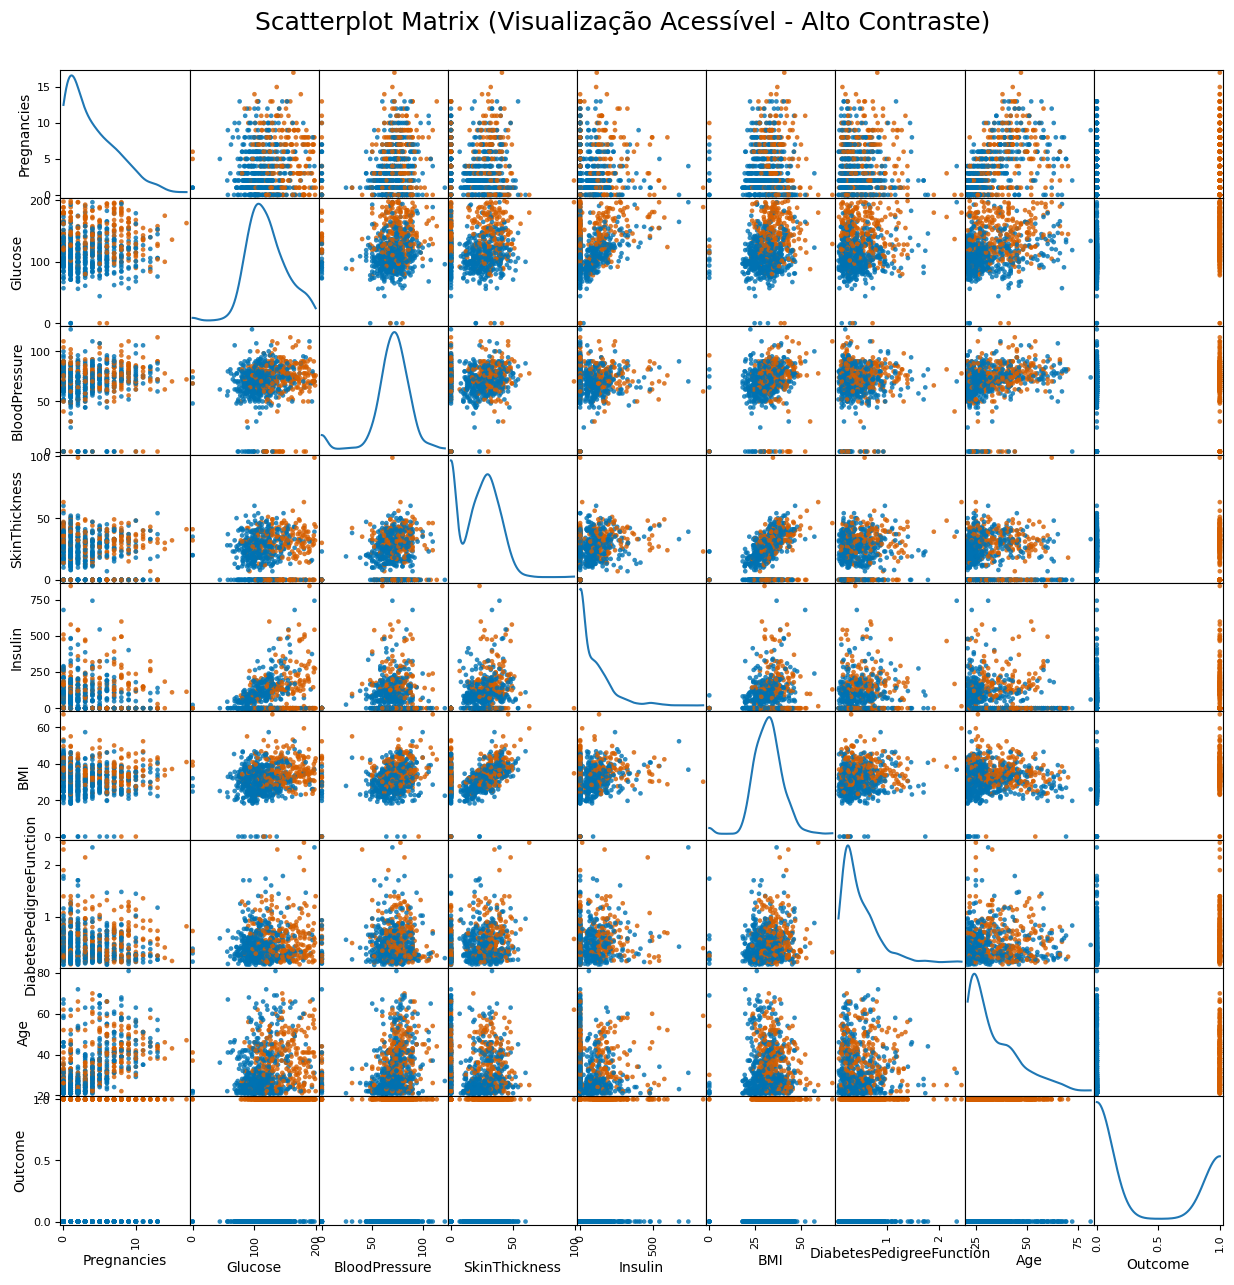

In [ ]:

fig, ax = plt.subplots(figsize=(15, 15))

pd.plotting.scatter_matrix(
    df, 
    alpha=0.8,      
    figsize=(15, 15), 
    diagonal='kde',

    color=df['Outcome'].map({0: '#0072B2', 1: '#D55E00'}), 
    ax=ax,
    s=45             
)
plt.suptitle("Scatterplot Matrix", y=0.92, fontsize=18)
plt.show()

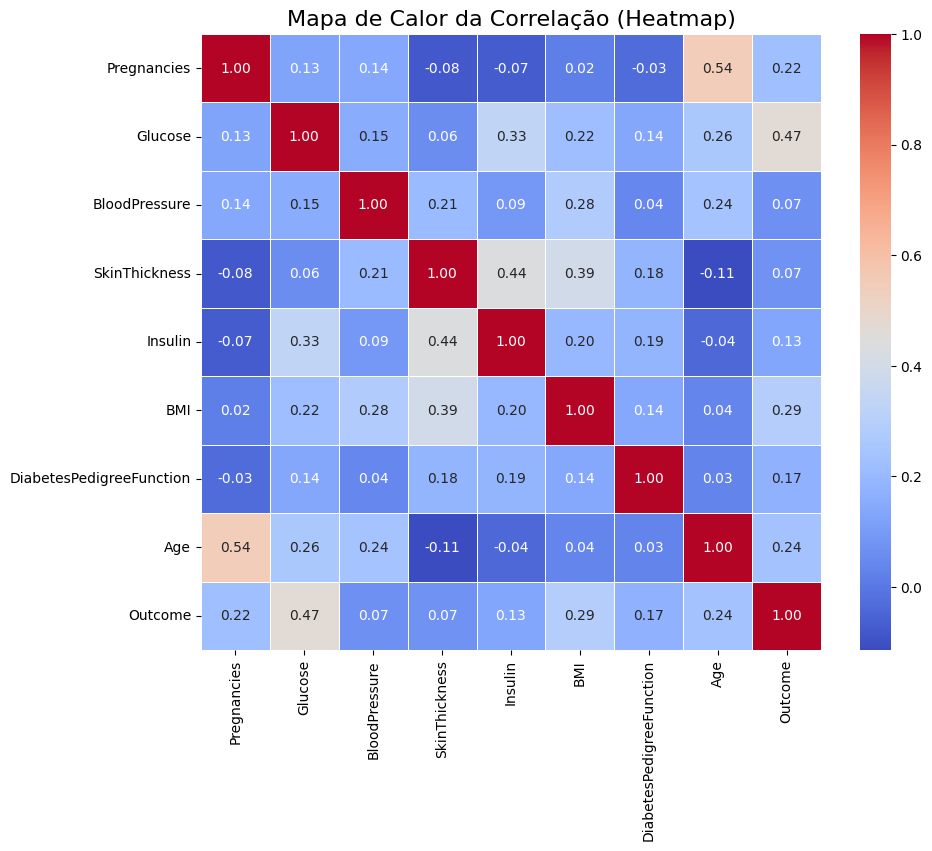

In [ ]:

plt.figure(figsize=(10, 8))
matriz_correlacao = df.corr()
# Desenhando o Mapa de Calor
sns.heatmap(
    matriz_correlacao, 
    annot=True,       
    cmap='coolwarm',   # Azul profundo = Negativo | Branco = Zero | Vermelho forte = Positivo
    fmt=".2f",        
    linewidths=0.5
)
plt.title("Mapa de Calor da Correlação (Heatmap)", fontsize=16)
plt.show()

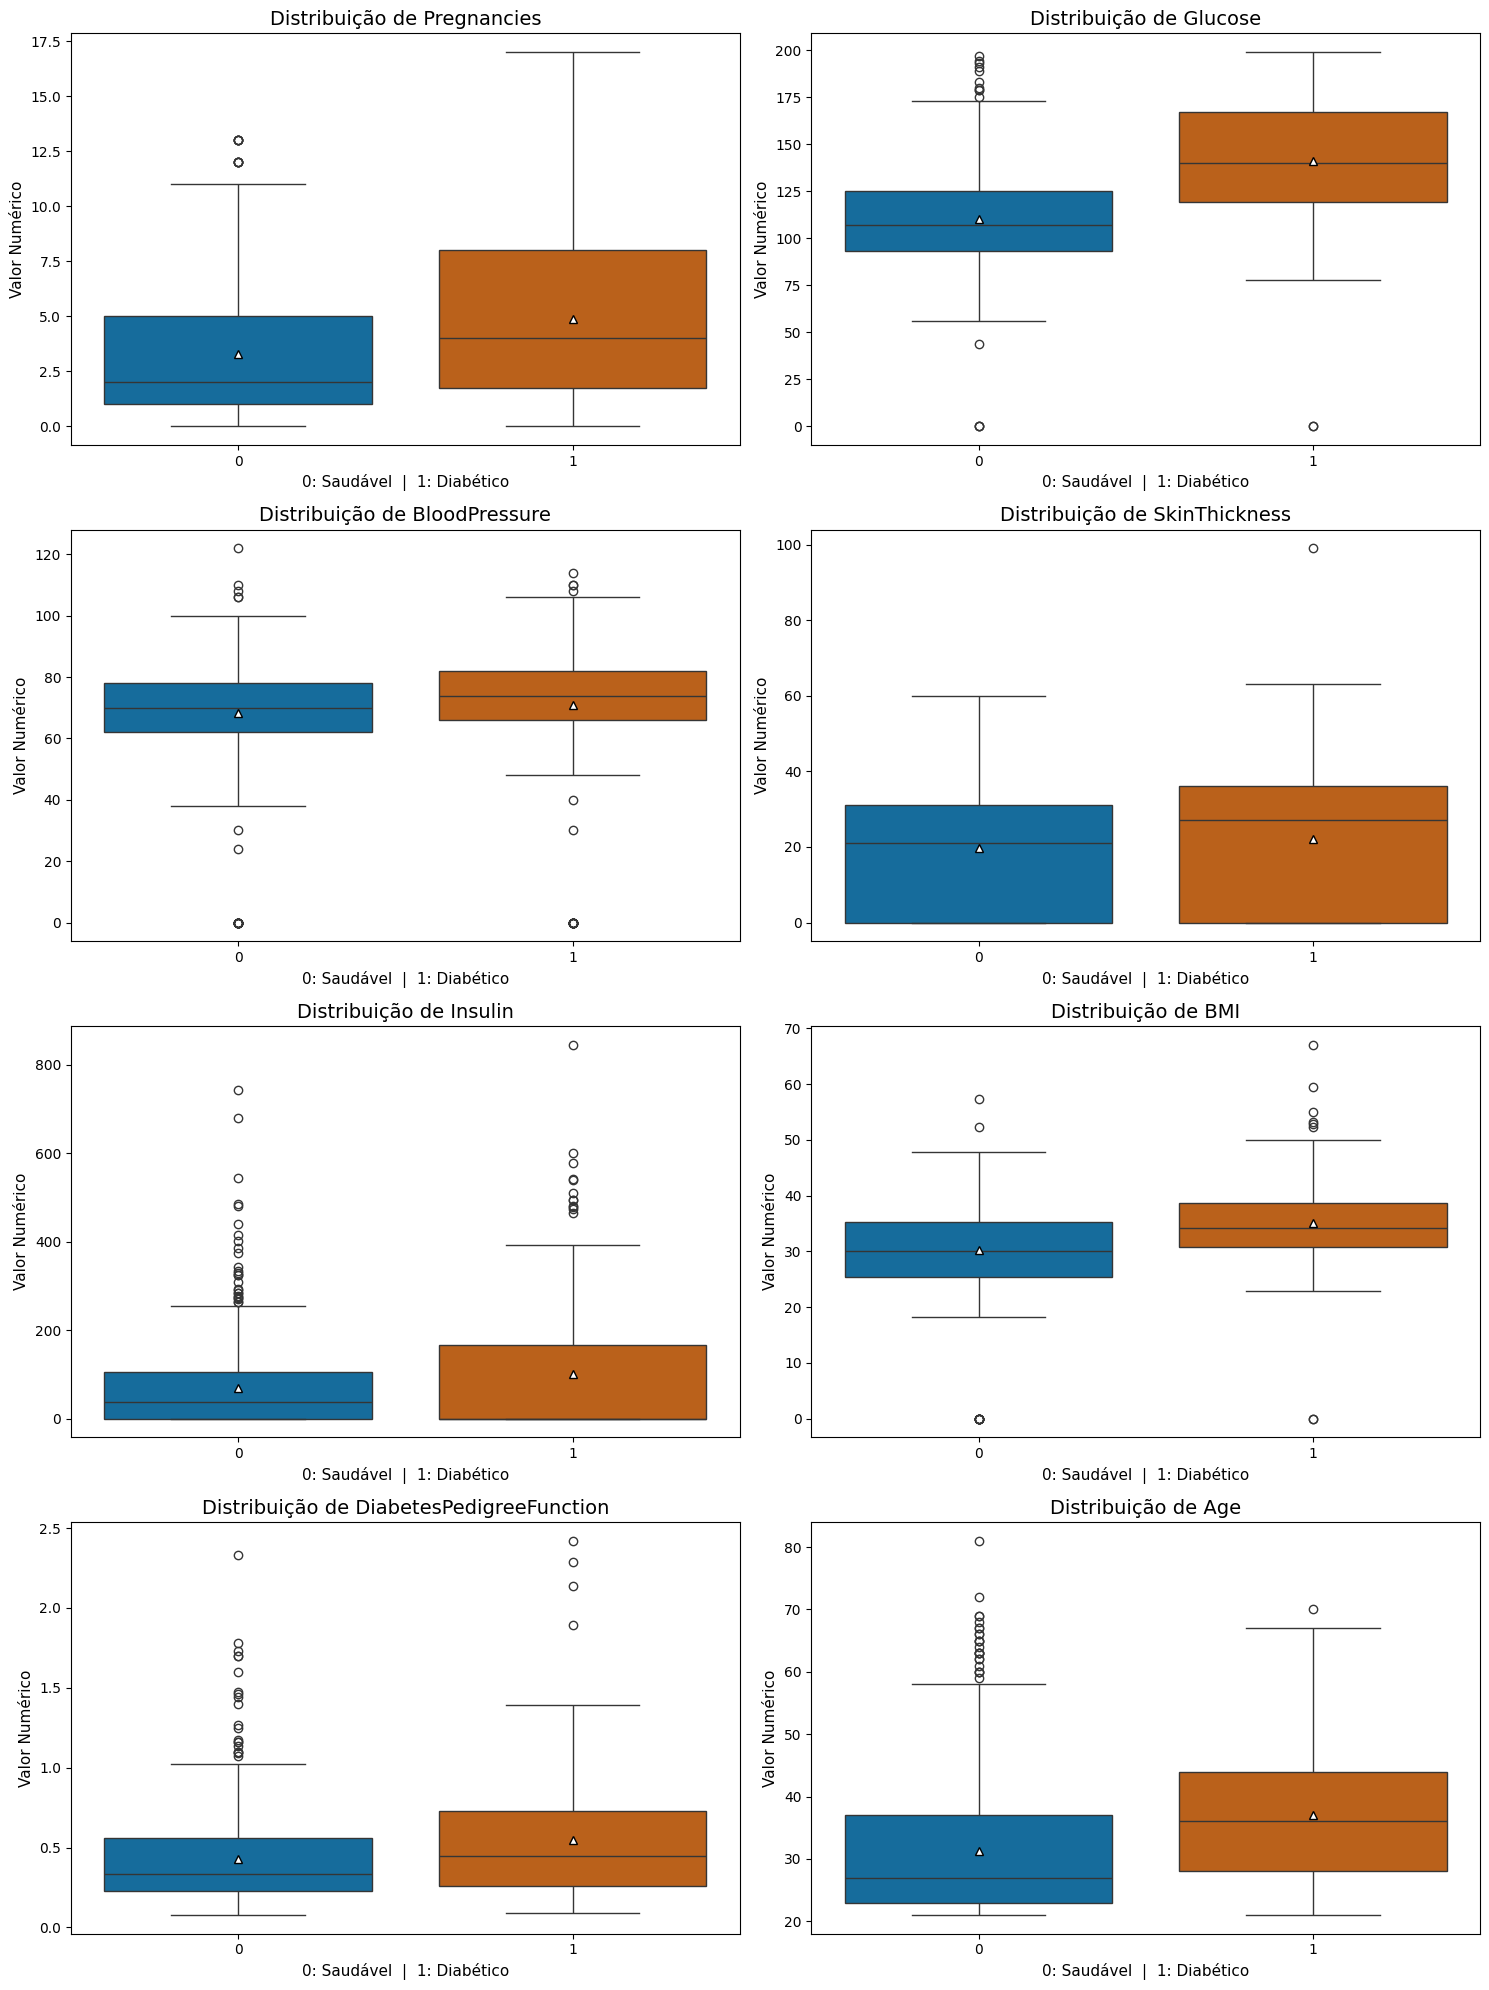

In [ ]:

todas_as_colunas = df.columns.drop('Outcome')

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

axes = axes.flatten()
for i, coluna in enumerate(todas_as_colunas):
    sns.boxplot(
        data=df, 
        x='Outcome', 
        y=coluna, 
        palette=["#0072B2", "#D55E00"], 
        showmeans=True, 
        meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black"},
        ax=axes[i]
    )
    axes[i].set_title(f'Distribuição de {coluna}', fontsize=14)
    axes[i].set_xlabel('0: Saudável  |  1: Diabético', fontsize=11)
    axes[i].set_ylabel('Valor Numérico', fontsize=11)
plt.tight_layout()
plt.show()


### Variáveis Preditivas Principais (Correlação com o Target `Outcome`)
A análise das métricas evidencia diferentes níveis de potencial preditivo entre as variáveis disponíveis:
* **Preditores Fortes:** As variáveis `Glucose` (**0.46**) e `BMI` (**0.29**) apresentam os maiores índices de correlação positiva com a prevalência da doença, configurando-se como os principais descritores para a construção do modelo.
* **Preditores Secundários:** Em um patamar secundário de relevância preditiva figuram as métricas contextuais do paciente, representadas pelas variáveis `Age` (**0.23**), `Pregnancies` (**0.22**) e `DiabetesPedigreeFunction` (**0.17**).
* **Preditores de Baixo Impacto:** Variáveis de natureza fisiológica contínua, especificamente `SkinThickness` (**0.07**) e `BloodPressure` (**0.06**), demonstram correlação quase nula com o desfecho. 

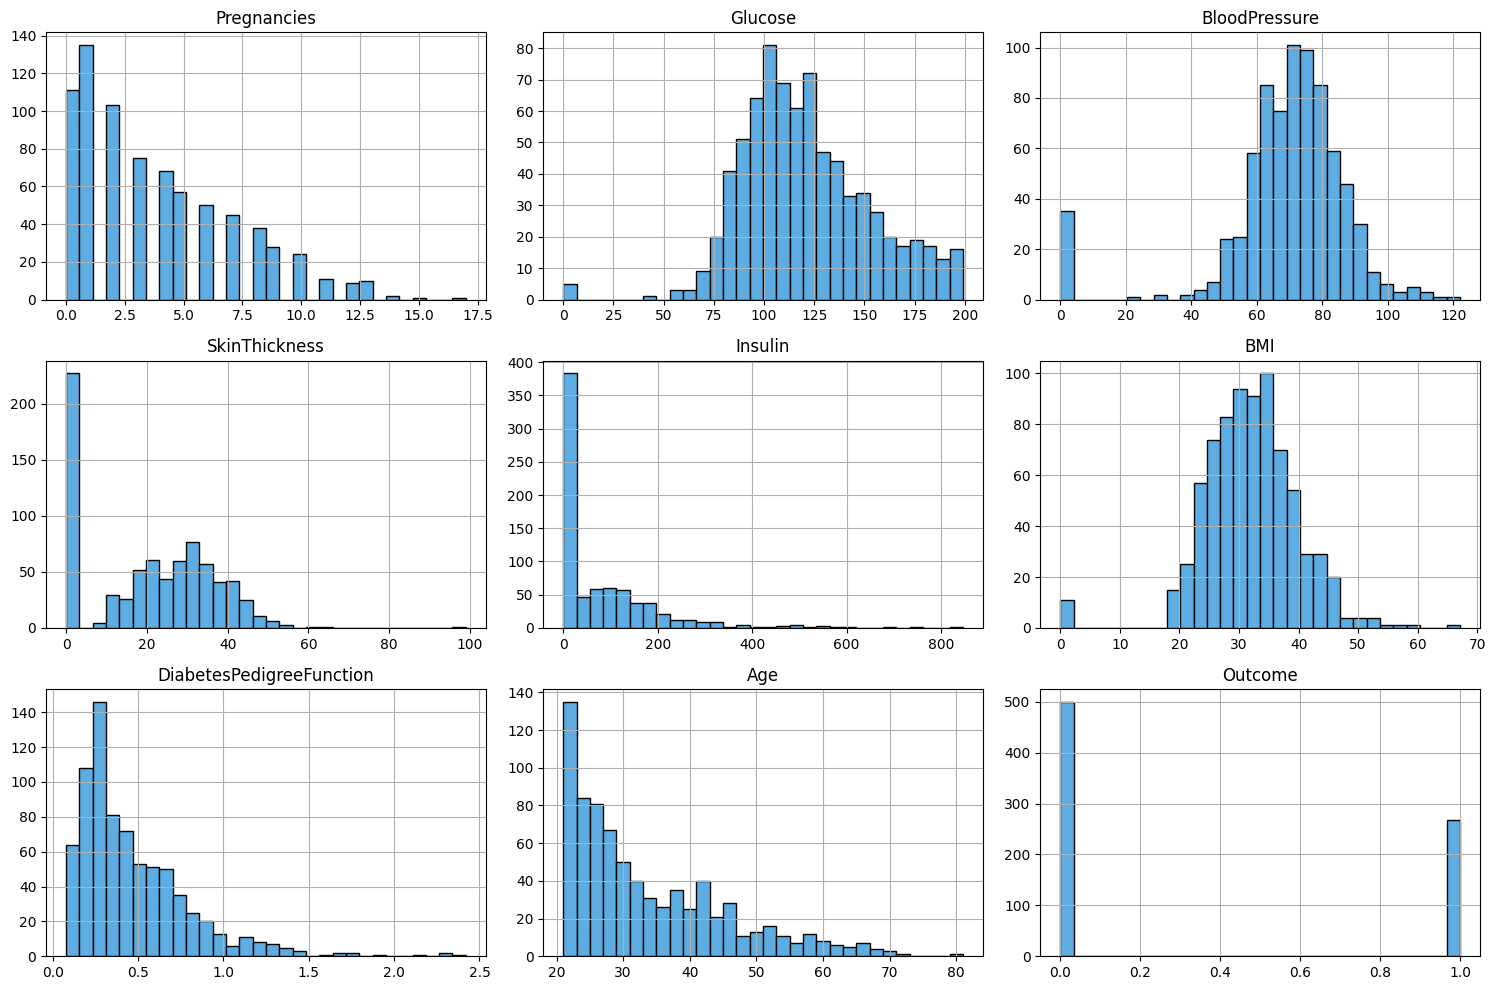

In [51]:
df.hist(bins=30, color='#5dade2', edgecolor='black')
# Exibe na tela
plt.tight_layout()
plt.show()

## Detectando outliers 

In [52]:
# Colunas biológicas que não podem ter valor zero
cols_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Soma a quantidade de zeros
zero_counts = (df[cols_to_check] == 0).sum()
# Calcula a porcentagem perante o total de linhas (len(df))
zero_percentages = round((zero_counts / len(df)) * 100, 2)
# Coloca num DataFrame pra visualizar bonito
zeros_info = pd.DataFrame({'Zeros (Qtd)': zero_counts, 'Percentual (%)': zero_percentages})
zeros_info.sort_values(by='Percentual (%)', ascending=False)

,Zeros (Qtd),Percentual (%)
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


## Estratégia de Pré-Processamento
Com base no que vimos nessa análise exploratória, definimos a seguinte rota antes de ir pra parte de modelagem:
* **Lidando com os zeros:** 
Tem bastante dado na base que tá com valor `0` onde é impossível (tipo pressão e IMC). Se a gente apagar essas linhas agora, vamos jogar fora quase metade do dataset. A ideia então é usar o `SimpleImputer` pra preencher esses buracos com a mediana. Só precisaremos lembrar de calcular essa mediana estritamente nos dados de Treino lá na frente, pra evitar *data leakage* com a base de teste.
* **Sem necessidade de PCA:**
Nossa base é super pequena, com só 8 colunas preditoras. Rodar redução de dimensionalidade (PCA) não faz sentido aqui. Se fizéssemos isso, a gente perderia a capacidade de entender qual coluna exata (como a Glicose) puxa mais o diagnóstico da doença, sem ganhar quase nada de performance em troca.

In [ ]:
#Preparacao das bases de treino e testes
X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)



In [ ]:

imputer = SimpleImputer(missing_values=0, strategy='median')
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_train[cols] = imputer.fit_transform(X_train[cols])
X_test[cols] = imputer.transform(X_test[cols])

🥇 Acurácia Geral do Modelo: 74.68%

📋 Relatório aprofundado:

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       100
           1       0.66      0.57      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.71       154
weighted avg       0.74      0.75      0.74       154



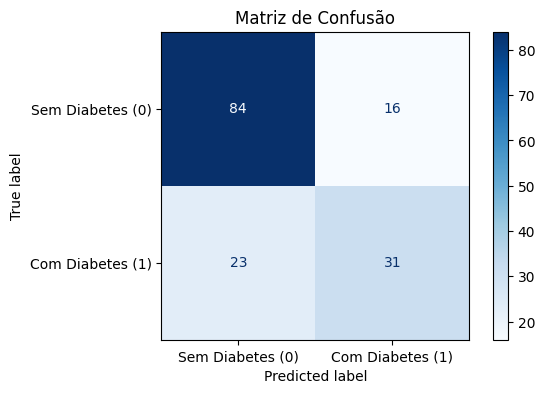

In [ ]:
# n_estimators=100 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(f"Acurácia Geral do Modelo: {accuracy_score(y_test, y_pred):.2%}")
print("\n📋 Relatório:\n")
print(classification_report(y_test, y_pred))
fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred), 
    display_labels=["Sem Diabetes (0)", "Com Diabetes (1)"]
)
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusão")


plt.show()

In [56]:

# 1. Definindo a "Caixa de Ferramentas" com os limites de altura das nossas florestas
parametros = {
    'max_depth': [3, 5, 8, 12],                # Limita a altura das árvores para elas não decorarem
    'min_samples_split': [2, 5, 10, 20],       # Amostras mínimas para dividir um galho
    'n_estimators': [50, 100, 200],            # Número de árvores vizinhas na floresta
    'max_features': ['sqrt', 'log2']           # Forma com que cada árvore enxerga a base de dados
}
# 2. Modelo Base
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
# 3. O Caçador de Modelos (GridSearch)
# O parâmetro scoring='recall' obriga o modelo focar na chance de não deixar diabéticos fugirem
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=parametros, 
    scoring='recall', 
    cv=5, 
    n_jobs=-1 # Usa todos os núcleos do processador para treinar mais rápido
)
# 4. Inicia o "Campeonato" das centenas de combinações no Processador!
print("Buscando o melhor formato da floresta...")
grid_search.fit(X_train, y_train)
# 5. Colhemos o campeão!
melhor_modelo = grid_search.best_estimator_
print("\n🏆 Melhores regras encontradas pro algoritmo:\n", grid_search.best_params_)
# 6. Avaliando o Novo Campeão na Base de Teste
y_pred_otimizado = melhor_modelo.predict(X_test)
print("\nNovo Boletim de Previsões:\n", classification_report(y_test, y_pred_otimizado))

Buscando o melhor formato da floresta...

🏆 Melhores regras encontradas pro algoritmo:
 {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}

Novo Boletim de Previsões:
               precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



In [57]:
# 1. Instanciamos o gerador de K-Nearest Neighbors (SMOTE)
smote = SMOTE(random_state=42)
# 2. Invocamos a geração de pacientes sintéticos DIABÉTICOS (Apenas no TREINO!)
# Perceba que os dados originais "X_train" e "y_train" saem transformados
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# Olha a mágica:
print("Placar de pacientes ANTES do SMOTE:\n", y_train.value_counts().to_dict())
print("Placar de pacientes DEPOIS do SMOTE:\n", y_train_smote.value_counts().to_dict())
# 3. Treinamos um NOVO modelo (agora sem o truque de 'class_weight') usando a base balanceada
# Já estamos usando os Hyperparâmetros Vencedores do passo anterior!
rf_smote = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    max_features='log2', 
    min_samples_split=10, 
    random_state=42
)
# Atenção: Treinamos na base gerada pelo SMOTE
rf_smote.fit(X_train_smote, y_train_smote)
# 4. Avaliamos a performance na base de Teste Limpa e Virgem (sem SMOTE nenhum!)
y_pred_smote = rf_smote.predict(X_test)
print("\n🌲 Relatório Otimizado com SMOTE:\n", classification_report(y_test, y_pred_smote))

Placar de pacientes ANTES do SMOTE:
 {0: 400, 1: 214}
Placar de pacientes DEPOIS do SMOTE:
 {0: 400, 1: 400}

🌲 Relatório Otimizado com SMOTE:
               precision    recall  f1-score   support

           0       0.87      0.71      0.78       100
           1       0.60      0.80      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



In [58]:
# 1. Aplicando o "StandardScaler" (Só o KNN precisa disso, o Random Forest não precisou!)
scaler = StandardScaler()
# Lembra da regra do Vazamento de Dados?
# Treinamos a régua (fit) só no Treino (agora balanceado pelo SMOTE) e aplicamos cegamente no Teste
X_train_knn = scaler.fit_transform(X_train_smote)
X_test_knn = scaler.transform(X_test)
# 2. Instanciando o KNN (Mandando ele olhar os 5 vizinhos mais parecidos com o paciente)
knn_model = KNeighborsClassifier(n_neighbors=5)
# 3. Treinando
knn_model.fit(X_train_knn, y_train_smote)
# 4. Avaliando Resultados
y_pred_knn = knn_model.predict(X_test_knn)
print("\n📏 Relatório do KNN (Com Dados Escalonados):\n", classification_report(y_test, y_pred_knn))


📏 Relatório do KNN (Com Dados Escalonados):
               precision    recall  f1-score   support

           0       0.83      0.69      0.75       100
           1       0.56      0.74      0.64        54

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.71       154



In [59]:
# 1. Definindo as "chaves de fenda" do KNN
parametros_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31], # O famoso "K"
    'weights': ['uniform', 'distance'],          # Peso simples vs dar mais peso pro vizinho mais próximo
    'metric': ['euclidean', 'manhattan']         # Diferentes formatos de régua matemática
}
# 2. Criamos o modelo KNN base
knn_base = KNeighborsClassifier()
# 3. O Caçador (GridSearch) focado em maximizar o Recall novamente!
grid_knn = GridSearchCV(
    estimator=knn_base, 
    param_grid=parametros_knn, 
    scoring='recall', 
    cv=5, 
    n_jobs=-1
)
# 4. Treinamos o GridSearch com os dados ESCALONADOS e com SMOTE (X_train_knn)
print("Buscando o KNN ideal...")
grid_knn.fit(X_train_knn, y_train_smote)
# 5. Descobrimos quem venceu a bateria de testes
melhor_knn = grid_knn.best_estimator_
print("\n🏆 Melhores hiperparâmetros do KNN:\n", grid_knn.best_params_)
# 6. Avaliando o Novo Campeão KNN na Base de Teste
y_pred_knn_otimizado = melhor_knn.predict(X_test_knn)
print("\n📏 Novo Boletim do KNN:\n", classification_report(y_test, y_pred_knn_otimizado))

Buscando o KNN ideal...

🏆 Melhores hiperparâmetros do KNN:
 {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}

📏 Novo Boletim do KNN:
               precision    recall  f1-score   support

           0       0.83      0.71      0.76       100
           1       0.57      0.72      0.64        54

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154



In [60]:
from sklearn.impute import KNNImputer
# --- PASSO 1: A Imputação Inteligente (Protegida contra Data Leakage) ---
# Trocando a Mediana de antes pelos 5 "Irmãos Gêmeos" de cada paciente
knn_imputer = KNNImputer(n_neighbors=5)
X_train_inteligente = X_train.copy()
X_test_inteligente = X_test.copy()
# Lembra? Aprende só no treino, e aplica cegamente no Teste!
X_train_inteligente[cols_to_check] = knn_imputer.fit_transform(X_train_inteligente[cols_to_check])
X_test_inteligente[cols_to_check] = knn_imputer.transform(X_test_inteligente[cols_to_check])
# --- PASSO 2: O SMOTE ---
X_train_smote_int, y_train_smote_int = smote.fit_resample(X_train_inteligente, y_train)
# --- PASSO 3: O GridSearch Focado em Acurácia ---
grid_accuracy = GridSearchCV(
    estimator=rf_base, 
    param_grid=parametros, # Lembre-se, os parametros já estavam definidos lá em cima
    scoring='accuracy',    # <---- O SEGREDO ESTÁ AQUI
    cv=5, 
    n_jobs=-1
)
print("Caçando os melhores Hyperparâmetros para máxima ACURÁCIA...")
grid_accuracy.fit(X_train_smote_int, y_train_smote_int)
melhor_rf_accuracy = grid_accuracy.best_estimator_
# --- PASSO 4: O Boletim Final ---
y_pred_acc = melhor_rf_accuracy.predict(X_test_inteligente)
print("\n🔥 Relatório Máximo de Acurácia do Kaggle:\n", classification_report(y_test, y_pred_acc))

Caçando os melhores Hyperparâmetros para máxima ACURÁCIA...

🔥 Relatório Máximo de Acurácia do Kaggle:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79       100
           1       0.62      0.69      0.65        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [61]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.impute import KNNImputer
# 1. DIVISÃO 70% Treino e 30% Teste
X_completo = df.drop(columns=['Outcome'])
y_completo = df['Outcome']
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X_completo, y_completo, test_size=0.3, stratify=y_completo, random_state=42)
# 2. LIMPEZA SEGURA (Enxuta e Direta sem Numpy)
colunas_criticas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# Avisamos a ferramenta para identificar diretamente o "0" como valor ausente e preencher
imputador_70_30 = KNNImputer(missing_values=0, n_neighbors=5)
X_train_70[colunas_criticas] = imputador_70_30.fit_transform(X_train_70[colunas_criticas])
X_test_30[colunas_criticas] = imputador_70_30.transform(X_test_30[colunas_criticas])
# 3. SMOTE PARA 70/30
smote_70 = SMOTE(random_state=42)
X_train_70_smote, y_train_70_smote = smote_70.fit_resample(X_train_70, y_train_70)
# 4. RANDOM FOREST 70/30
rf_70_30 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    max_features='log2', 
    min_samples_split=10, 
    random_state=42
)
rf_70_30.fit(X_train_70_smote, y_train_70_smote)
# 5. O GRANDE TESTE REAL NOS 30%
y_pred_30 = rf_70_30.predict(X_test_30)
print("🎯 BOLETIM FINAL (70/30 com Imputação Direta de Zeros):\n")
print(classification_report(y_test_30, y_pred_30))

🎯 BOLETIM FINAL (70/30 com Imputação Direta de Zeros):

              precision    recall  f1-score   support

           0       0.86      0.76      0.81       150
           1       0.63      0.77      0.69        81

    accuracy                           0.76       231
   macro avg       0.74      0.76      0.75       231
weighted avg       0.78      0.76      0.77       231

